findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


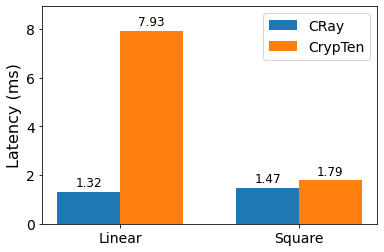

In [15]:
import matplotlib.pyplot as plt

# Set the font to Times New Roman
plt.rc('font', family='Times New Roman')

fig, ax = plt.subplots(figsize=(6, 4))

# Define the categories and their respective values
categories = ["Linear", "Square"]
CRay_values = [1.32, 1.47]
CrypTen_values = [7.93, 1.79]

# Define bar width and positions
bar_width = 0.35
positions = range(len(categories))

# Plot CRay and CrypTen bars next to each other for each category
CRay_bars = ax.bar([p - bar_width/2 for p in positions], CRay_values, bar_width, label="CRay", color="#1f77b4")
CrypTen_bars = ax.bar([p + bar_width/2 for p in positions], CrypTen_values, bar_width, label="CrypTen", color="#ff7f0e")

# Adding labels and title
ax.set_ylabel("Latency (ms)")
# ax.set_title("Comparison of CRay and CrypTen by Operation Type")
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_ylim(0, max(CrypTen_values) + 1)

# Add value labels on top of bars
for bars, values in zip([CRay_bars, CrypTen_bars], [CRay_values, CrypTen_values]):
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.1, round(value, 2), ha='center', va='bottom')

# Add legend
ax.legend()

plt.savefig("comparison_plot.pdf", format="pdf")
plt.show()


<Figure size 432x288 with 0 Axes>

In [10]:
import plotly.graph_objects as go

# Define the categories and their respective values
categories = ["Linear", "Square"]
CRay_values = [1.32, 1.47]
CrypTen_values = [7.93, 1.79]

# Create a Plotly figure
fig = go.Figure()

# Add CRay bars
fig.add_trace(go.Bar(
    x=categories,
    y=CRay_values,
    name="CRay",
    marker_color="#1f77b4"
))

# Add CrypTen bars
fig.add_trace(go.Bar(
    x=categories,
    y=CrypTen_values,
    name="CrypTen",
    marker_color="#ff7f0e"
))

# Customize layout
fig.update_layout(
    # title="Comparison of CRay and CrypTen by Operation Type",
    xaxis_title="Operation Type",
    yaxis_title="Value",
    barmode='group',
    yaxis=dict(range=[0, max(CrypTen_values) + 1]),
    template="plotly_white"
)

# Add value labels on top of bars
for i, (cray_val, crypten_val) in enumerate(zip(CRay_values, CrypTen_values)):
    fig.add_annotation(x=categories[i], y=cray_val + 0.1, text=str(round(cray_val, 2)), showarrow=False, font=dict(size=12))
    fig.add_annotation(x=categories[i], y=crypten_val + 0.1, text=str(round(crypten_val, 2)), showarrow=False, font=dict(size=12), xshift=30)

# Show the figure
fig.show()
